In [5]:
import sys
sys.path.append("../")

from methods.Steepest_descent import (gradient_descent)
from methods.Error import (save_iterations, history, calculate_precision, plot_methods_error, ten_iterations)
from methods.Newton_method import (newton_method)
from methods.Conjugate_method import (conjugate_gradient)
import numpy as np
import os
import matplotlib.pyplot as plt

No convergence
-----------------------------
Method:  Gradient_descent
Minimum point:  [2.9021762  0.48368759]
Function value at minimum:  9.157782118791985e-05
Number of iterations:  1000
-----------------------------


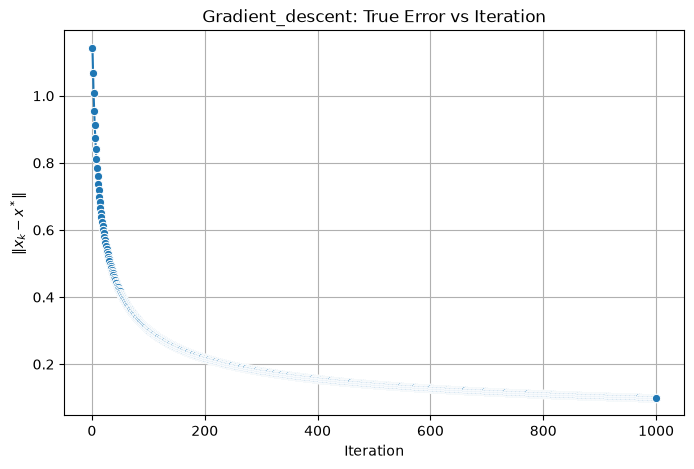

-----------------------------
Method:  Newton Method
Minimum point:  [2.99999538 0.49999923]
Function value at minimum:  4.544855495531734e-22
Number of iterations:  33
-----------------------------


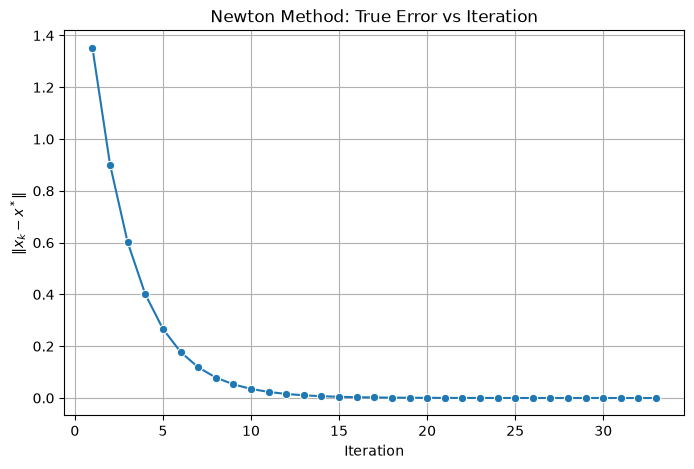

-----------------------------
Method:  Conjugate Gradient Method
Minimum point:  [3.00019757 0.50003293]
Function value at minimum:  1.523626347713394e-15
Number of iterations:  83
-----------------------------


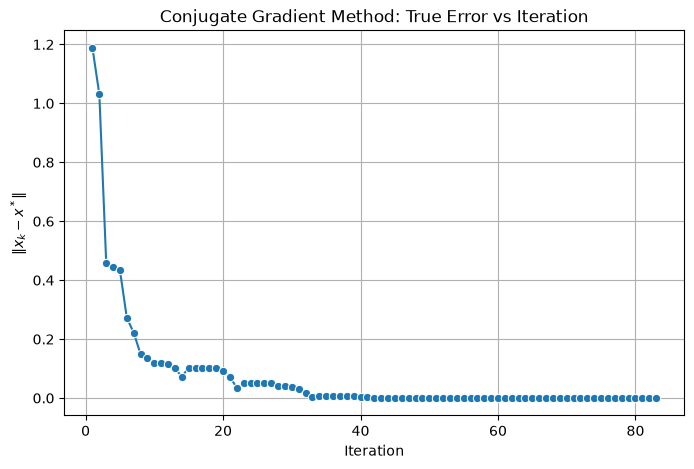

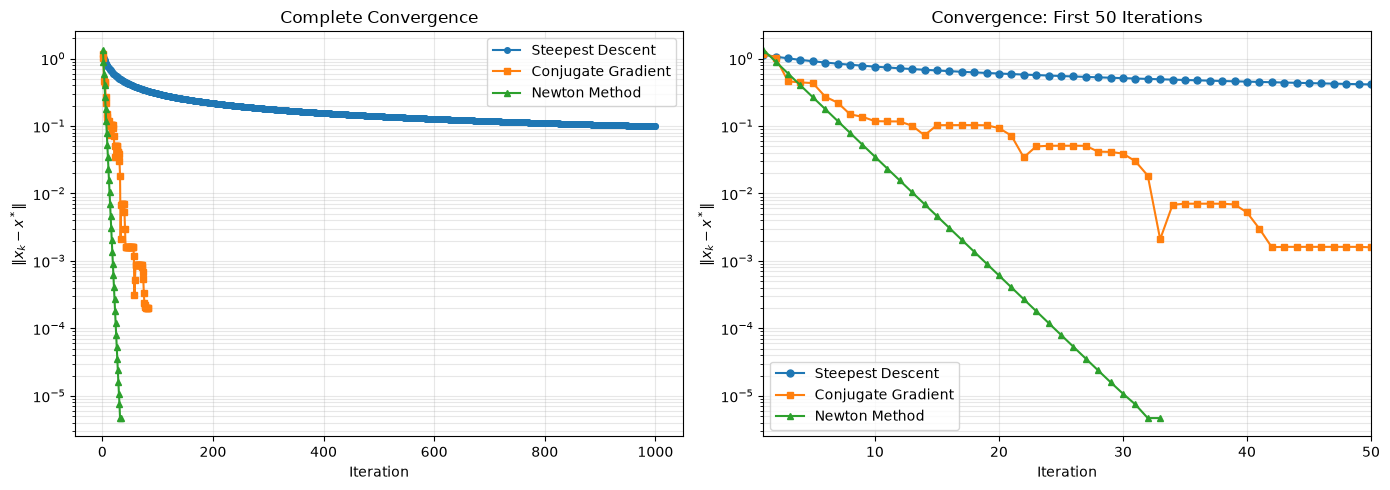

Plot saved: results\plots\methods_comparison_error.png
               Method  Iterations  Final Error  Correct Decimals
0    Steepest Descent        1000     0.099175                 0
1  Conjugate Gradient          83     0.000200                 3
2       Newton Method          33     0.000005                 5

Database saved: results\methods_precision.csv
                Method  iteration        x1        x2       f(x)  gradient_x1  \
0     Steepest Descent          1  1.877178  0.288722   1.610418   -66.000000   
1     Steepest Descent          2  1.948583  0.311823   1.228109    -5.372597   
2     Steepest Descent          3  2.008311  0.324206   0.971147    -4.493980   
3     Steepest Descent          4  2.058482  0.334266   0.788601    -3.774952   
4     Steepest Descent          5  2.101446  0.342701   0.653940    -3.232680   
5     Steepest Descent          6  2.138812  0.349916   0.551581    -2.811479   
6     Steepest Descent          7  2.171722  0.356186   0.471855    -2.

In [ ]:
def f(x, y):
    # Set the constant used in the function
    d = 3
    # Calculate the objective function
    return (((x - d) ** 4) + (x - 2 * d * y) ** 2)

# Partial derivatives
def df_dx(x, y):
    # Set the constant used in the function
    d = 3
    # Calculate the partial derivative with respect to x
    return (4 * (x - d) ** 3 + 2 * x - 4 * d * y)

def df_dy(x, y):
    # Set the constant used in the function
    d = 3
    # Calculate the partial derivative with respect to y
    return (-(4 * d) * (x - 2 * d * y))

# Gradient
def gradient(x, y):
    # Combine both partial derivatives into the gradient vector
    return np.array([df_dx(x, y), df_dy(x, y)])

def hessian(x, y):
    # Set the constant used in the function
    d = 3
    # Build the Hessian matrix using the second partial derivatives
    return np.array([[12 * ((x - d) ** 2) + 2, -4 * d],
                     [-4 * d, 8 * d ** 2]])

def printing(method, minimum, f_min, iterations):
    # Print the main results of the optimization method
    print("-----------------------------")
    print("Method: ", method)
    print("Minimum point: ", minimum)
    print("Function value at minimum: ", f_min)
    print("Number of iterations: ", iterations)
    print("-----------------------------")

# Set the constant and initial point
d = 3
x0 = np.array([1.0, d])

# Set the convergence parameters
tol = 1e-10
max_iter = 1000
alpha = 0.01329058

# Set the identity matrix and the known solution
H = np.eye(2)
x_true = [3, 1 / 2]

# Main
if __name__ == "__main__":
    # Run Gradient Descent
    minimum, f_min, iterations, history_data = gradient_descent(
        x0, f, gradient, tol, max_iter, alpha, history
    )
    printing("Gradient_descent", minimum, f_min, iterations)
    df_gradient = save_iterations(
        history_data, "Gradient_descent", x_true
    )

    # Run Newton's Method
    minimum, f_min, iterations, history_data = newton_method(
        x0, f, gradient, hessian, tol, max_iter, alpha, history
    )
    printing("Newton Method", minimum, f_min, iterations)
    df_newton = save_iterations(
        history_data, "Newton Method", x_true
    )

    # Run Conjugate Gradient
    minimum, f_min, iterations, history_data = conjugate_gradient(
        x0, f, gradient, tol, max_iter, history
    )
    printing("Conjugate Gradient Method", minimum, f_min, iterations)
    df_conjugate = save_iterations(
        history_data, "Conjugate Gradient Method", x_true
    )

    # Set the folder where all the results are stored
    results_path = "results"

    # Compare the error convergence of all three methods
    plot_methods_error(results_path)

    # Calculate the final precision of each method
    calculate_precision(results_path)

    # Create a table with the first 10 iterations
    ten_iterations(results_path)